Nizam Shaikh - 24198170

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jackksoncsie/spam-email-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Nizam\.cache\kagglehub\datasets\jackksoncsie\spam-email-dataset\versions\1


In [2]:
import pandas as pd
data= pd.read_csv(path+'/emails.csv')
data[:3]

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1


In [3]:
data['spam'].value_counts()

spam
0    4360
1    1368
Name: count, dtype: int64

In [4]:
import pandas as pd
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nizam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Nizam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [5]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    # Step 1: Case Normalization
    text = text.lower()
    
    # Step 2: Remove Numbers
    text = re.sub(r'\d+', '', text)
    
    # Step 3: Remove Punctuation & Special Characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Step 4: Tokenization
    tokens = text.split()
    
    # Step 5: Remove Stop Words
    tokens = [w for w in tokens if w not in stop_words]
    
    # Step 6: Stemming
    tokens = [ps.stem(w) for w in tokens]
    
    # Join back to string
    return ' '.join(tokens)

In [6]:
data['clean_text'] = data['text'].apply(preprocess)

In [7]:
data[['text', 'clean_text']].head(5)

,text,clean_text
0,Subject: naturally irresistible your corporate...,subject natur irresist corpor ident lt realli ...
1,Subject: the stock trading gunslinger fanny i...,subject stock trade gunsling fanni merril muzo...
2,Subject: unbelievable new homes made easy im ...,subject unbeliev new home made easi im want sh...
3,Subject: 4 color printing special request add...,subject color print special request addit info...
4,"Subject: do not have money , get software cds ...",subject money get softwar cd softwar compat gr...


In [8]:
# Check no empty results
print("Null values:", data['clean_text'].isnull().sum())
print("Empty strings:", (data['clean_text'] == '').sum())

# Update features to use clean text
features = data['clean_text']
label    = data['spam']

print("\nSample clean text:")
print(features[0])

Null values: 0
Empty strings: 0

Sample clean text:
subject natur irresist corpor ident lt realli hard recollect compani market full suqgest inform isoverwhelminq good catchi logo stylish statloneri outstand websit make task much easier promis havinq order iogo compani automaticaili becom world ieader isguit ciear without good product effect busi organ practic aim hotat nowaday market promis market effort becom much effect list clear benefit creativ hand made origin logo special done reflect distinct compani imag conveni logo stationeri provid format easi use content manag system letsyou chang websit content even structur prompt see logo draft within three busi day afford market break make gap budget satisfact guarante provid unlimit amount chang extra fee surethat love result collabor look portfolio interest


In [9]:
features=data.text
label=data.spam

In [10]:
# WordCLoud - SPAM
import sys
!{sys.executable} -m pip install wordcloud

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

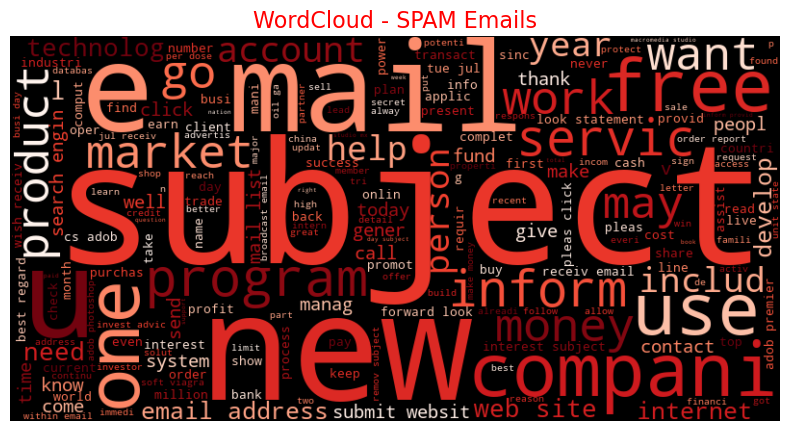

In [12]:
spam_text = ' '.join(data[data['spam'] == 1]['clean_text'])

wordcloud_spam = WordCloud(width=800, height=400,
                           background_color='black',
                           colormap='Reds').generate(spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - SPAM Emails', fontsize=16, color='red')
plt.show()

In [13]:
# # WordCLoud - NotSPAM

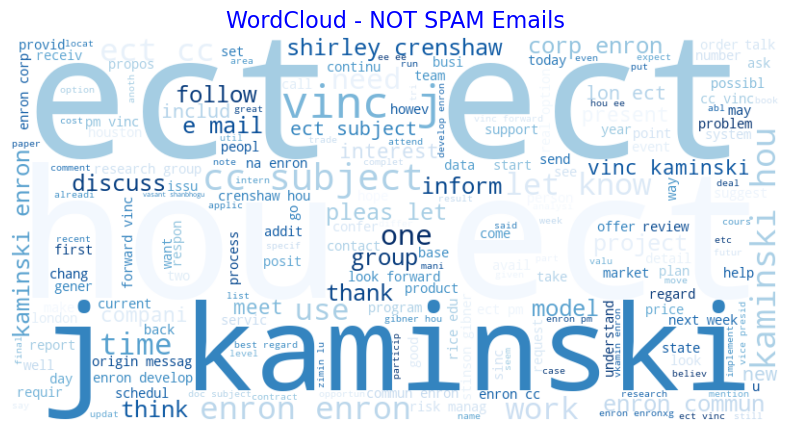

In [14]:
notspam_text = ' '.join(data[data['spam'] == 0]['clean_text'])

wordcloud_notspam = WordCloud(width=800, height=400,
                              background_color='white',
                              colormap='Blues').generate(notspam_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_notspam, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - NOT SPAM Emails', fontsize=16, color='blue')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(features,label,test_size=0.2)

In [16]:
#Bow/CountVectofzier
from sklearn.feature_extraction.text import CountVectorizer
vector=CountVectorizer()

train_feature=vector.fit_transform(x_train)
test_feature=vector.transform(x_test)


In [17]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer()

# Fit on training data, transform both train & test
train_tfidf = tfidf.fit_transform(x_train)
test_tfidf  = tfidf.transform(x_test)

print("Train shape:", train_tfidf.shape)
print("Test shape :", test_tfidf.shape)

Train shape: (4582, 33444)
Test shape : (1146, 33444)


In [18]:
import pandas as pd

# Show top 10 words with highest TF-IDF scores from first email
feature_names = tfidf.get_feature_names_out()
first_email   = train_tfidf[0]

scores = zip(feature_names, first_email.toarray()[0])
top10  = sorted(scores, key=lambda x: x[1], reverse=True)[:10]

print("Top 10 TF-IDF words in first email:\n")
for word, score in top10:
    print(f"  {word:20s} → {score:.4f}")

Top 10 TF-IDF words in first email:

  probabilities        → 0.3551
  currency             → 0.3320
  table                → 0.2922
  multiplied           → 0.2392
  pessimetic           → 0.2392
  togetrher            → 0.2392
  equally              → 0.2091
  rab                  → 0.2049
  achieving            → 0.1880
  approx               → 0.1762


In [19]:
#GloVe
import sys
!{sys.executable} -m pip install gensim

In [20]:
import gensim.downloader as api

# Downloads GloVe trained on Twitter (25d = 25 numbers per word, small & fast)
glove_model = api.load("glove-twitter-25")

print("GloVe loaded")
print("Vector size:", glove_model.vector_size)

GloVe loaded
Vector size: 25


In [21]:
import numpy as np

def email_to_glove(text):
    words   = text.split()
    # Get vector for each word if it exists in GloVe
    vectors = [glove_model[w] for w in words if w in glove_model]
    # Average all word vectors into one vector
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(glove_model.vector_size)  # unknown words → zeros

# Apply to train and test sets
train_glove = np.array([email_to_glove(t) for t in x_train])
test_glove  = np.array([email_to_glove(t) for t in x_test])

print("Train shape:", train_glove.shape)
print("Test shape :", test_glove.shape)

Train shape: (4582, 25)
Test shape : (1146, 25)


In [22]:
# See what the word 'free' looks like as numbers
print("Vector for 'free':\n")
print(glove_model['free'])

Vector for 'free':

[-0.014577  1.1052   -0.32093  -0.35025   0.65034  -0.17946   1.0967
  0.21447   0.56527   0.19124   0.5733    0.18844  -4.1624   -0.67647
 -0.33129  -0.38925   0.65206  -1.1814   -0.27982   0.20279  -1.0775
 -1.1988   -0.090183  0.054852 -0.10991 ]


In [23]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_glove = RandomForestClassifier()
rf_glove.fit(train_glove, y_train)

pred_glove = rf_glove.predict(test_glove)
print("GloVe + RF Accuracy:", accuracy_score(y_test, pred_glove))

GloVe + RF Accuracy: 0.9258289703315882


In [28]:
#GBM
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier()
gbm.fit(train_tfidf, y_train)
gbm_pred = gbm.predict(test_tfidf)

In [29]:
from sklearn.svm import SVC

svm = SVC(probability=True)  # probability=True needed for ROC curve later
svm.fit(train_tfidf, y_train)
svm_pred = svm.predict(test_tfidf)

In [30]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(train_tfidf.toarray(), y_train)   # GNB needs dense array
gnb_pred = gnb.predict(test_tfidf.toarray())

In [34]:
from sklearn.metrics import classification_report

models_pred = {
    'GBM' : gbm_pred,
    'SVM' : svm_pred,
    'GNB' : gnb_pred,
    'RF'  : pred_glove
}

for name, pred in models_pred.items():
    print(f"\n{'='*40}")
    print(f"  {name} Classification Report")
    print(f"{'='*40}")
    print(classification_report(y_test, pred,
          target_names=['Not Spam', 'Spam']))


  GBM Classification Report
              precision    recall  f1-score   support

    Not Spam       0.96      0.98      0.97       854
        Spam       0.95      0.89      0.92       292

    accuracy                           0.96      1146
   macro avg       0.96      0.94      0.95      1146
weighted avg       0.96      0.96      0.96      1146


  SVM Classification Report
              precision    recall  f1-score   support

    Not Spam       0.99      1.00      1.00       854
        Spam       1.00      0.98      0.99       292

    accuracy                           0.99      1146
   macro avg       1.00      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146


  GNB Classification Report
              precision    recall  f1-score   support

    Not Spam       0.96      0.98      0.97       854
        Spam       0.94      0.88      0.91       292

    accuracy                           0.95      1146
   macro avg       0.95      0.93      0.

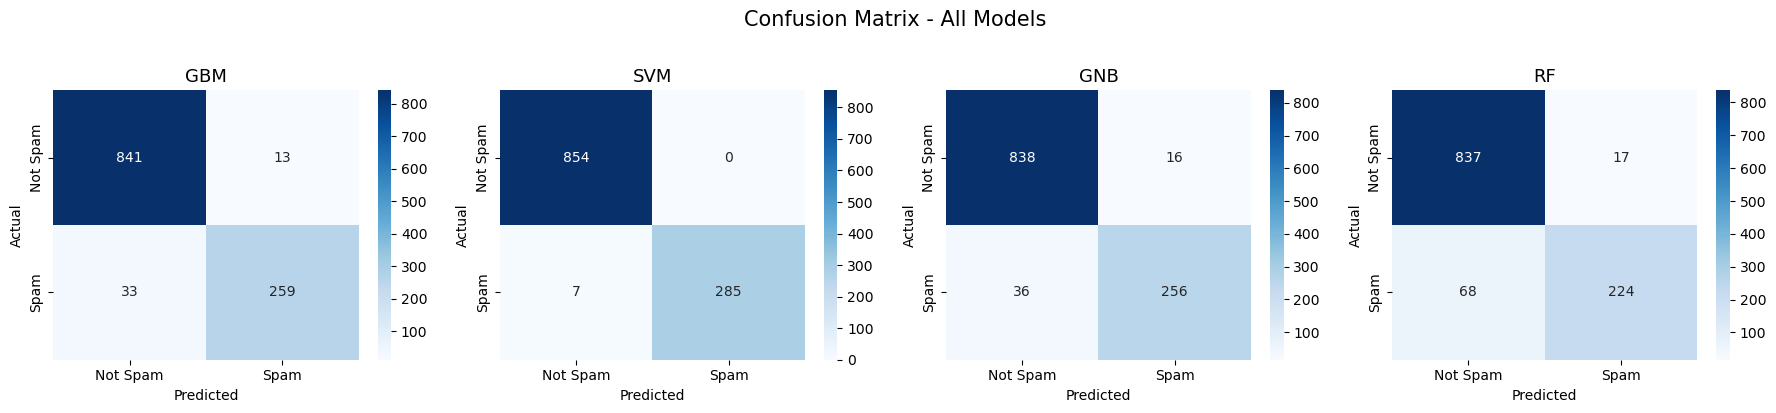

In [35]:
#Confusion MAtrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, pred) in zip(axes, models_pred.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Spam','Spam'],
                yticklabels=['Not Spam','Spam'])
    ax.set_title(f'{name}', fontsize=13)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix - All Models', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [37]:
# RF trained on TF-IDF features (separate from the original rf which used BoW)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(train_tfidf, y_train)
rf_pred = rf.predict(test_tfidf)

print("RF retrained on TF-IDF ✅")

RF retrained on TF-IDF ✅


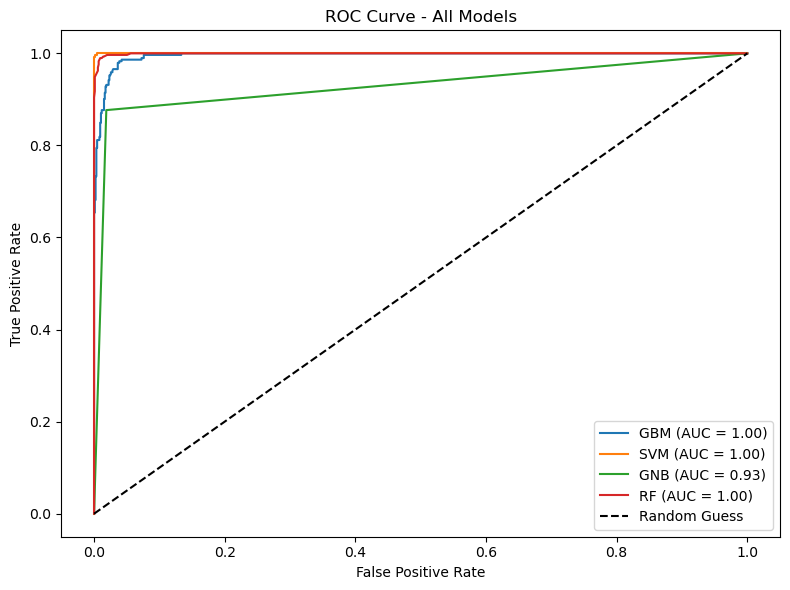

In [39]:
from sklearn.metrics import roc_curve, auc

# Get probability scores for each model
models_proba = {
    'GBM' : gbm.predict_proba(test_tfidf)[:, 1],
    'SVM' : svm.predict_proba(test_tfidf)[:, 1],
    'GNB' : gnb.predict_proba(test_tfidf.toarray())[:, 1],
    'RF'  : rf.predict_proba(test_tfidf)[:, 1]
}

plt.figure(figsize=(8, 6))

for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

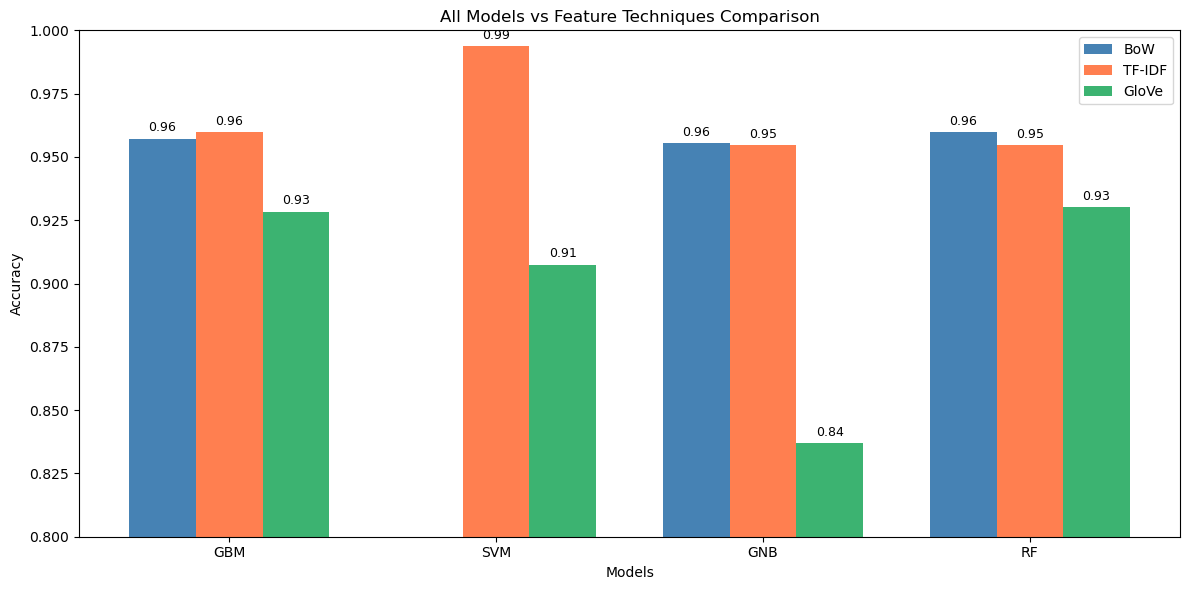

In [40]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

# ── Accuracy using BoW ──────────────────────────────────────────
bow_scores = {
    'GBM' : accuracy_score(y_test, gbm.predict(test_feature)),
    'SVM' : accuracy_score(y_test, svm.predict(test_feature)),
    'GNB' : accuracy_score(y_test, GaussianNB().fit(train_feature.toarray(), y_train).predict(test_feature.toarray())),
    'RF'  : accuracy_score(y_test, rf.predict(test_feature))
}

# ── Accuracy using TF-IDF ───────────────────────────────────────
tfidf_scores = {
    'GBM' : accuracy_score(y_test, gbm_pred),
    'SVM' : accuracy_score(y_test, svm_pred),
    'GNB' : accuracy_score(y_test, gnb_pred),
    'RF'  : accuracy_score(y_test, rf_pred)
}

# ── Accuracy using GloVe ────────────────────────────────────────
glove_scores = {}
for name, model in [('GBM', GradientBoostingClassifier()),
                    ('SVM', SVC()),
                    ('GNB', GaussianNB()),
                    ('RF',  RandomForestClassifier())]:
    model.fit(train_glove, y_train)
    glove_scores[name] = accuracy_score(y_test, model.predict(test_glove))

# ── Plot Bar Chart ──────────────────────────────────────────────
labels  = ['GBM', 'SVM', 'GNB', 'RF']
x       = np.arange(len(labels))
width   = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width, bow_scores.values(),   width, label='BoW',    color='steelblue')
ax.bar(x,         tfidf_scores.values(), width, label='TF-IDF', color='coral')
ax.bar(x + width, glove_scores.values(), width, label='GloVe',  color='mediumseagreen')

ax.set_xlabel('Models')
ax.set_ylabel('Accuracy')
ax.set_title('All Models vs Feature Techniques Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.8, 1.0)
ax.legend()

# Add value labels on top of each bar
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()